In [33]:
import os

os.environ['KAGGLE_USERNAME'] = 'Yash Gouthariya'
os.environ['KAGGLE_KEY'] = 'KGAT_8b4f901c29d15e10c6e67b0538a36509'

!rm -rf isic2019_dataset
!rm -f isic-2019.zip

!pip install -q --upgrade kaggle
!kaggle datasets download -d andrewmvd/isic-2019
!unzip -q isic-2019.zip -d isic2019_dataset

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/isic-2019
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 9.10G/9.10G [01:45<00:00, 92.5MB/s]



In [34]:

print("Folder contents:")
print(os.listdir('./isic2019_dataset'))

Folder contents:
['ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv', 'ISIC_2019_Training_Metadata.csv']


In [35]:
import pandas as pd

dataset_dir = './isic2019_dataset'

csv_path = os.path.join(dataset_dir, "ISIC_2019_Training_GroundTruth.csv")

print(os.listdir("./isic2019_dataset"))
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("Sample data:")
    print(df.head(3))
    print(f"\nTotal rows in CSV: {len(df)}")

train_img_dir = os.path.join(dataset_dir, 'train')
if os.path.exists(train_img_dir):
    images = os.listdir(train_img_dir)
    print(f"\n Found {len(images)} images in '{train_img_dir}'")

['ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv', 'ISIC_2019_Training_Metadata.csv']
Sample data:
          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0

Total rows in CSV: 25331


In [36]:
import torch
import numpy as np
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import pandas as pd

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

def find_image_folder(base_dir):
    for root, dirs, files in os.walk(base_dir):
        if len(dirs) > 0 and all(os.path.isdir(os.path.join(root, d)) for d in dirs):
            return root
    return base_dir

df = pd.read_csv(csv_path)
print("diseases and their number of images:")
print(df.sum())

diseases and their number of images:
image    ISIC_0000000ISIC_0000001ISIC_0000002ISIC_00000...
MEL                                                 4522.0
NV                                                 12875.0
BCC                                                 3323.0
AK                                                   867.0
BKL                                                 2624.0
DF                                                   239.0
VASC                                                 253.0
SCC                                                  628.0
UNK                                                    0.0
dtype: object


In [37]:
import os
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, random_split

dataset_dir = "./isic2019_dataset"

csv_path = os.path.join(dataset_dir, "ISIC_2019_Training_GroundTruth.csv")
image_dir = os.path.join(dataset_dir, "ISIC_2019_Training_Input","ISIC_2019_Training_Input")
print(os.listdir(image_dir)[:10])

df = pd.read_csv(csv_path)

# Remove UNK class (optional)
df = df[df["UNK"] == 0].reset_index(drop=True)

class_names = ["MEL", "NV", "BCC", "AK", "BKL", "DF", "VASC", "SCC"]
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of images:", len(df))

class ISICDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = os.path.join(
            self.image_dir,
            row["image"] + ".jpg"
        )

        image = Image.open(image_path).convert("RGB")

        label = row[class_names].values.argmax()

        if self.transform:
            image = self.transform(image)

        return image, label

full_dataset = ISICDataset(
    df,
    image_dir,
    transform=data_transforms['train']
)

val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

train_dataset.dataset.transform = data_transforms['train']
val_dataset.dataset.transform = data_transforms['val']

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print(f"Training Images: {train_size}")
print(f"Validation Images: {val_size}")

['ISIC_0061066.jpg', 'ISIC_0031359.jpg', 'ISIC_0032509.jpg', 'ISIC_0026996.jpg', 'ISIC_0032930.jpg', 'ISIC_0025316.jpg', 'ISIC_0056997.jpg', 'ISIC_0033593.jpg', 'ISIC_0028727.jpg', 'ISIC_0012653_downsampled.jpg']
Classes: ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
Number of images: 25331
Training Images: 20265
Validation Images: 5066


In [38]:
import os
print(os.listdir("./isic2019_dataset/ISIC_2019_Training_Input")[:10])

print(num_classes)

img, label = full_dataset[0]
print(label)
print(class_names[label])
for i in range(10):
  _,label = full_dataset[i]
  print(i,label, class_names[label])

['ISIC_2019_Training_Input']
8
1
NV
0 1 NV
1 1 NV
2 0 MEL
3 1 NV
4 0 MEL
5 1 NV
6 1 NV
7 1 NV
8 1 NV
9 1 NV


In [39]:
print(os.path.exists("./isic2019_dataset/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ISIC_0064519.jpg"))
len(os.listdir("./isic2019_dataset/ISIC_2019_Training_Input/ISIC_2019_Training_Input"))

True


25333

In [41]:
print(df[df["image"] == "ISIC_0064519"])

              image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
19808  ISIC_0064519  0.0  0.0  1.0  0.0  0.0  0.0   0.0  0.0  0.0


In [40]:
print(len(df))

25331


In [43]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(image_dir)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

history = {'train_loss': [], 'val_loss': [], 'top1_acc': [], 'top5_acc': []}

def top_k_accuracy(output, target, k=5):
    with torch.no_grad():
        maxk = min(k, output.shape[1])
        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        return correct[:maxk].reshape(-1).float().sum(0, keepdim=True).item() / target.size(0)

EPOCHS = 10  # Can Increase epochs for better accuracy

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / train_size

    model.eval()
    val_loss = 0.0
    top1_correct = 0
    top5_correct = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            top1_correct += (outputs.argmax(dim=1) == labels).sum().item()
            if num_classes >= 5:
                top5_correct += top_k_accuracy(outputs, labels, k=5) * labels.size(0)



    epoch_val_loss = val_loss / val_size
    epoch_top1_acc = top1_correct / val_size
    epoch_top5_acc = top5_correct / val_size if num_classes >= 5 else 1.0

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['top1_acc'].append(epoch_top1_acc)
    history['top5_acc'].append(epoch_top5_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Top-1 Acc: {epoch_top1_acc:.4f}")

Using Device: cuda:0
./isic2019_dataset/ISIC_2019_Training_Input/ISIC_2019_Training_Input
Epoch [1/10] - Train Loss: 0.8463 | Val Loss: 0.7271 | Top-1 Acc: 0.7357
Epoch [2/10] - Train Loss: 0.5348 | Val Loss: 0.6385 | Top-1 Acc: 0.7736
Epoch [3/10] - Train Loss: 0.2978 | Val Loss: 0.6393 | Top-1 Acc: 0.7872
Epoch [4/10] - Train Loss: 0.1600 | Val Loss: 0.6766 | Top-1 Acc: 0.8040
Epoch [5/10] - Train Loss: 0.0980 | Val Loss: 0.8318 | Top-1 Acc: 0.7949
Epoch [6/10] - Train Loss: 0.0845 | Val Loss: 0.8132 | Top-1 Acc: 0.7714
Epoch [7/10] - Train Loss: 0.0671 | Val Loss: 0.8292 | Top-1 Acc: 0.7902
Epoch [8/10] - Train Loss: 0.0564 | Val Loss: 0.9817 | Top-1 Acc: 0.7872
Epoch [9/10] - Train Loss: 0.0705 | Val Loss: 0.7967 | Top-1 Acc: 0.8034
Epoch [10/10] - Train Loss: 0.0495 | Val Loss: 1.0375 | Top-1 Acc: 0.7902


In [44]:
import torch.nn.functional as F
from sklearn.metrics import classification_report, accuracy_score

model.eval()
all_preds = []
all_labels = []
all_confidences = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)

        probabilities = F.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probabilities, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confidences.extend(confidences.cpu().numpy())

overall_accuracy = accuracy_score(all_labels, all_preds)
avg_confidence = np.mean(all_confidences)

print(f"====================================")
print(f"Overall Test Accuracy: {overall_accuracy * 100:.2f}%")
print(f"Average Prediction Confidence Score: {avg_confidence * 100:.2f}%")
print(f"====================================\n")

print("Detailed Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

Overall Test Accuracy: 79.02%
Average Prediction Confidence Score: 93.28%

Detailed Classification Report:

              precision    recall  f1-score   support

         MEL       0.71      0.63      0.67       862
          NV       0.82      0.94      0.88      2616
         BCC       0.82      0.76      0.79       720
          AK       0.58      0.49      0.53       158
         BKL       0.73      0.53      0.61       493
          DF       0.79      0.44      0.57        52
        VASC       0.82      0.84      0.83        49
         SCC       0.59      0.43      0.50       116

    accuracy                           0.79      5066
   macro avg       0.73      0.63      0.67      5066
weighted avg       0.78      0.79      0.78      5066



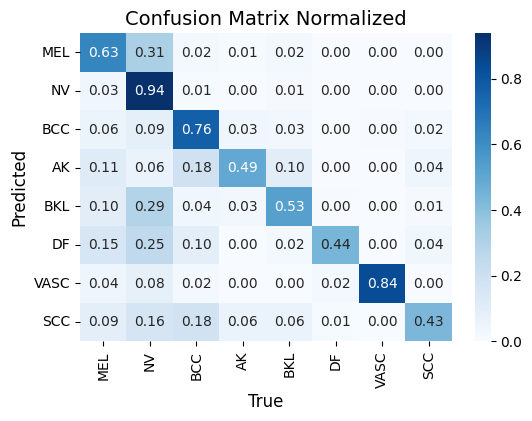

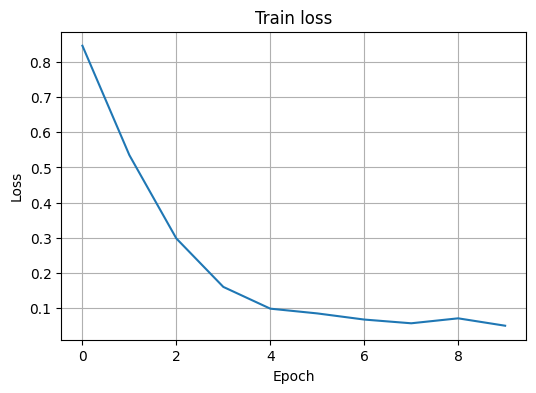

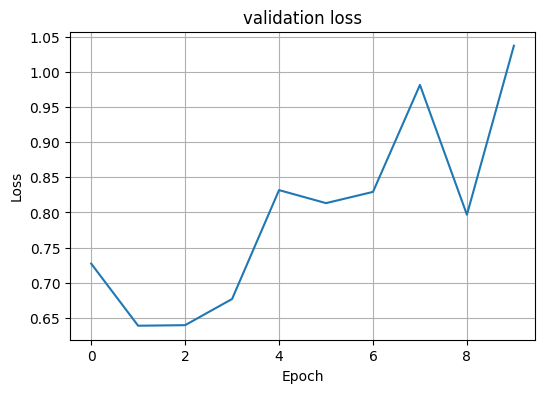

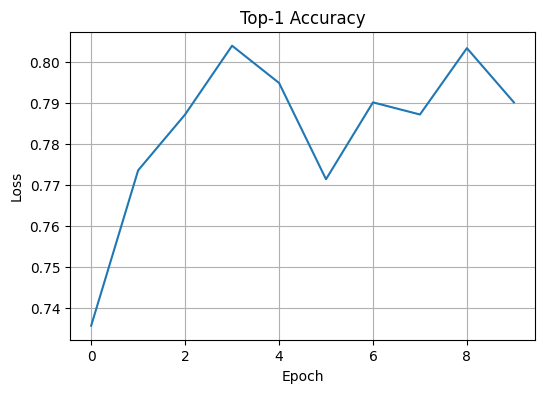

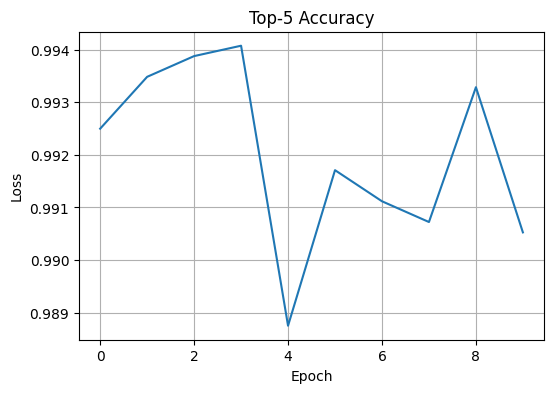

In [46]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


# Plot 1: Normalized Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.title("Confusion Matrix Normalized", fontsize=14)
plt.xlabel("True", fontsize=12)
plt.ylabel("Predicted", fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Plot 2: Training & Metrics Grid
plt.figure(figsize=(6,4))
plt.plot(history['train_loss'])
plt.title("Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history['val_loss'])
plt.title("validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history['top1_acc'])
plt.title("Top-1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history['top5_acc'])
plt.title("Top-5 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()



Actual sample skin disease images for all classes:


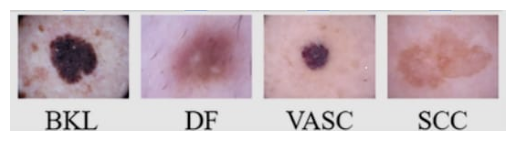

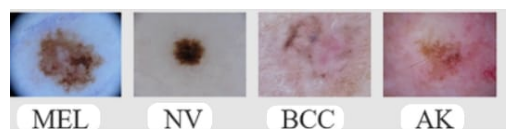

In [51]:
from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open("First_four.jpeg")
img2 = Image.open("Second_four.jpeg")

print("Actual sample skin disease images for all classes:")

plt.imshow(img1)
plt.axis("off")
plt.show()

plt.imshow(img2)
plt.axis("off")
plt.show()

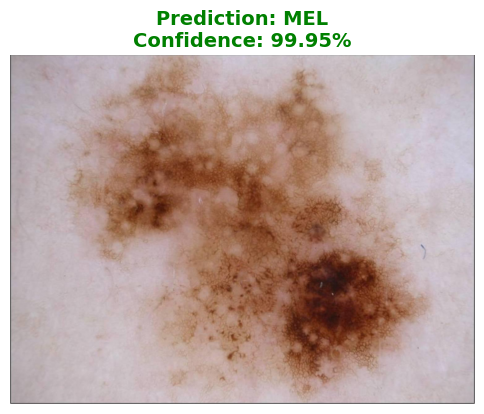


--- Class Probabilities for: ISIC_0000049.jpg ---
MEL                           : 99.95%
NV                            : 0.05%
BKL                           : 0.00%
VASC                          : 0.00%
DF                            : 0.00%
SCC                           : 0.00%
BCC                           : 0.00%
AK                            : 0.00%


In [52]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import os

def predict_custom_image(image_path, model, class_names, transform, device):

    raw_img = Image.open(image_path).convert('RGB')
    input_tensor = transform(raw_img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]


    confidence, pred_class_idx = torch.max(probabilities, dim=0)
    predicted_class = class_names[pred_class_idx.item()]


    plt.figure(figsize=(6, 6))
    plt.imshow(raw_img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence.item() * 100:.2f}%",
              fontsize=14, color='green', fontweight='bold')
    plt.show()


    print(f"\n--- Class Probabilities for: {os.path.basename(image_path)} ---")
    prob_dict = {class_names[i]: probabilities[i].item() * 100 for i in range(len(class_names))}
    for label, prob in sorted(prob_dict.items(), key=lambda x: x[1], reverse=True):
        print(f"{label:<30}: {prob:.2f}%")


test_image_path = 'ISIC_0000049.jpg'
if os.path.exists(test_image_path):
    predict_custom_image(
        image_path=test_image_path,
        model=model,
        class_names=class_names,
        transform=data_transforms['val'],
        device=device
    )
else:
    print(f"File '{test_image_path}' not found! Please upload your test image to Colab first.")